# ML-10 — Content Action Playbook

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/flyrank-bih/flyrank-ml-internship-starter/blob/main/work/notebooks/w07_action_playbook.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Ranked actions + reason codes

*The queue: what to do first, and why, in words a human trusts.*

In [2]:
# Rank the FULL dataset by model_score (the validated model from Week 5/6)
df_ranked = df.sort_values("model_score", ascending=False).copy()

# Archetype -> action mapping (human-readable reason codes -> what to actually do)
# Reuses the Week-4 baseline reason codes as the "archetype", paired with the model's
# score for prioritization within each archetype.
archetype_actions = {
    "stale_and_weak_ctr": "Refresh title, opening, and update stale facts/examples",
    "stale_only": "Light refresh: update dates/stats, check for stale sections",
    "weak_ctr_only": "Rewrite title and meta description to better match position",
    "no_flag": "No action needed based on current signals",
}
df_ranked["recommended_action"] = df_ranked["reason_code"].map(archetype_actions)

# Confidence note: how far above/below the tier's typical CTR is this item?
tier_avg_ctr = df_ranked.groupby("position_tier")["ctr"].transform("mean")
df_ranked["ctr_vs_tier_avg"] = df_ranked["ctr"] - tier_avg_ctr

print("Top 10 ranked actions:")
print(df_ranked[["content_id", "client_id", "model_score", "reason_code",
                  "recommended_action", "ctr_vs_tier_avg", "days_since_last_update"]].head(10).to_string(index=False))

# Precision@K, worded per the claim ladder ("the model ranks/flags... at precision@K of...")
for k in [10, 20, 50]:
    p = precision_at_k(df_ranked["model_score"], df_ranked["is_declining"], k)
    print(f"Model ranks the top {k}: precision@{k} = {p:.3f} (base rate {df['is_declining'].mean():.3f})")

Top 10 ranked actions:
          content_id         client_id  model_score   reason_code                                          recommended_action  ctr_vs_tier_avg  days_since_last_update
content_4560b0a818ab client_19581e27de     0.999998 weak_ctr_only Rewrite title and meta description to better match position        -0.442467                      22
content_8e7ba84a972b client_7f2253d7e2     0.999480       no_flag                   No action needed based on current signals         0.267533                      20
content_c8ad1f4d0e56 client_7f2253d7e2     0.993627       no_flag                   No action needed based on current signals         2.747533                      20
content_a22b7f6c73c5 client_7f2253d7e2     0.989353       no_flag                   No action needed based on current signals         4.127533                      20
content_70b8f5323e29 client_7f2253d7e2     0.975944       no_flag                   No action needed based on current signals         0.856761

The model ranks/flags the top 10 items at precision@10 of 0.700, the top 20 at 0.800, and the top 50 at 0.780, against a base rate of 0.542.

A limitation worth stating plainly: the reason codes above (stale_and_weak_ctr, stale_only, weak_ctr_only, no_flag) come from the Week-4 rule-based baseline, but the model ranking the queue relies on different signals (engagement quality metrics like users_90d/sessions_90d, per the Week-5 interpretation), not staleness or CTR directly. As a result, most of the model's top-ranked items carry a no_flag reason code, since the baseline rule wouldn't have caught them, which means the recommended action text ("no action needed") is misleading for exactly the items the model considers most urgent. A more honest playbook would pair the model's own top features with a matching action (e.g., "declining engagement pattern, review for relevance/quality issues") rather than reusing the baseline's reason codes as if they explain the model's reasoning.

Also worth naming: 8 of the top 10 ranked items belong to a single client (client_7f2253d7e2), so an editor working across multiple clients may want a per-client top-N view rather than one global ranking.

## 2. Intended use and limits

*Who uses this, for what — and where it stops being valid.*

In [3]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.


Intended use and limits

Who uses this: A content editor at a FlyRank client, deciding which declining content to review first when they don't have time to check everything (per the Week-3 frame).

What it's for: A prioritized starting point for manual review, not an automated action. The model ranks content by likelihood of decline, using engagement and visibility signals (per Week-5's feature importance: users_90d, sessions_90d, days_since_last_update, among others). An editor should treat the ranking as "review this first," then apply their own judgment about the actual fix.

Where it stops being valid:

This is cross-sectional, observational data from one snapshot, not a controlled experiment. Per the claim ladder, that means we can say the model "ranks/flags content at precision@K of X," but never that refreshing a page "will cause" its decline to reverse. That would require an intervention design we don't have.
The model was validated with a grouped-by-client split, so it's tested on generalizing to unseen clients, but it hasn't been tested across a real future time window (the starter dataset is a single snapshot, not the full 17-month warehouse panel).
As found in section 1, the model performs unevenly across position tiers (notably weaker, higher error, at top_3 content per Week 6's error analysis), and top-ranked results can concentrate heavily on a single client, so a per-client or per-tier review may be more reliable than trusting one global ranking blindly.
The reason codes shown alongside the ranking come from the separate Week-4 rule baseline, not from the model itself, so they should be read as a rough secondary signal, not an explanation of why the model ranked an item highly.

## 3. Human review + the no-go list

*What a person must check before acting. What should never be automated.*

In [4]:
# How many distinct clients appear in the top 50, and how unevenly?
top50 = df_ranked.head(50)
print("Client distribution in top 50 ranked items:")
print(top50["client_id"].value_counts())

# How much training data did each client actually contribute? (small clients = less reliable predictions)
client_counts = df["client_id"].value_counts()
print("\nSmallest clients by row count (potential low-confidence predictions):")
print(client_counts.tail(5))

# Content type mix in the top 50 - does one type dominate?
print("\nContent type mix in top 50:")
print(top50["content_type"].value_counts())

Client distribution in top 50 ranked items:
client_id
client_7f2253d7e2    19
client_f369cb89fc    14
client_d029fa3a95     7
client_6208ef0f77     6
client_19581e27de     2
client_624b60c58c     1
client_a88a7902cb     1
Name: count, dtype: int64

Smallest clients by row count (potential low-confidence predictions):
client_id
client_02d20bbd7e    38
client_0b918943df    35
client_4fc82b26ae    32
client_8b940be7fb    28
client_1a6562590e     3
Name: count, dtype: int64

Content type mix in top 50:
content_type
keyword article       43
comparison article     6
feedly article         1
Name: count, dtype: int64


This confirms real patterns worth building into the no-go list.

Key observations:

Client concentration is real and severe: just 2 clients (client_7f2253d7e2 and client_f369cb89fc) account for 33 of the top 50 items (66%). A "global top 50" queue mostly serves two accounts and could leave other clients' declining content invisible.
A client with only 3 total rows exists (client_1a6562590e). Any prediction for that client rests on almost no data, and the model has essentially no way to have learned that client's normal behavior.
Content type is heavily skewed toward keyword article (43 of 50) — worth flagging as a caveat to check against the full dataset's natural mix, since this could just reflect proportions rather than a real bias.

Section 3 text:

Human review + the no-go list

What a person must check before acting:

Which client an item belongs to, and whether that client is already over-represented in the queue. In this data, 2 of 32 clients account for two-thirds of the top-50 ranked items, so an editor should confirm they aren't only ever seeing the same one or two clients' content and neglecting others.
How much data exists for that client overall. One client in this dataset has only 3 total rows; a prediction built on that little history should be treated as low-confidence and reviewed manually before any action is taken.
Whether the actual content still makes business sense to keep or refresh at all (the model has no knowledge of business priorities, seasonal relevance, or whether a page is still strategically important).
The real reason behind a high score, by reading the actual page, not just trusting the reason code, since section 1 showed the reason codes don't always match what the model is actually responding to.

What should never be automated:

Auto-publishing any title, opening, or content change based on the model's ranking. The model has no understanding of the content's actual meaning or quality, it only sees behavioral and structural signals.
Auto-deprioritizing or removing content flagged as "no action needed." A low score reflects the model's current signals, not a guarantee the content is fine, especially for low-data clients or a underrepresented client in this queue.
Treating the ranking as valid for a client with very little historical data (like the 3-row client above) without flagging it for lower-confidence handling first.
Blind trust in top_3-positioned content rankings, since Week 6's error analysis showed the model performs worst exactly there.

## 4. Monitoring / retrain triggers

*What would tell you the recommendations went stale?*

In [5]:
# Record current performance as the reference point any future drop should be compared against
current_precision = {}
for k in [10, 20, 50]:
    current_precision[k] = precision_at_k(df_ranked["model_score"], df_ranked["is_declining"], k)

current_base_rate = df["is_declining"].mean()

print("Current reference metrics (compare future runs against these):")
for k, p in current_precision.items():
    print(f"precision@{k}: {p:.3f}")
print(f"base_rate: {current_base_rate:.3f}")

# Reference client mix — a future run with a very different distribution signals population drift
print("\nCurrent client count and size distribution (reference for drift check):")
print(f"Total clients: {df['client_id'].nunique()}")
print(df["client_id"].value_counts().describe())

# Reference feature distributions for the top model features (from Week 5's importance ranking)
print("\nReference stats for top model features (compare future data against these):")
print(df[["users_90d", "sessions_90d", "days_since_last_update"]].describe())

Current reference metrics (compare future runs against these):
precision@10: 0.700
precision@20: 0.800
precision@50: 0.780
base_rate: 0.542

Current client count and size distribution (reference for drift check):
Total clients: 32
count      32.000000
mean      937.500000
std      1376.387113
min         3.000000
25%       110.250000
50%       567.000000
75%      1058.750000
max      7008.000000
Name: count, dtype: float64

Reference stats for top model features (compare future data against these):
          users_90d  sessions_90d  days_since_last_update
count  30000.000000  30000.000000            30000.000000
mean      35.937700     37.066633               46.098300
std      103.748185    107.069131               42.078709
min        1.000000      1.000000                1.000000
25%        2.000000      2.000000               20.000000
50%        7.000000      7.000000               20.000000
75%       27.000000     27.000000              104.000000
max     4913.000000   4345.00000

Good, this confirms and sharpens the picture — notice the massive client size imbalance: client sizes range from 3 rows to 7,008 rows (mean 937, std 1,376), meaning some clients have over 2,000x more data than others. That's a much stronger, more specific point than a vague "clients differ."

Section 4 — final text:

Monitoring / retrain triggers

Performance drift: Current reference metrics are precision@10 = 0.700, precision@20 = 0.800, precision@50 = 0.780, against a base rate of 0.542. If a future run's precision@K drops meaningfully below these numbers, especially toward the 0.542 base rate, the ranking has stopped adding value over random ordering and needs investigation or retraining.

Population drift: Client sizes in this dataset range from 3 rows to 7,008 rows (mean 937.5, std 1,376), an enormous imbalance. If a future client's row count falls far below the current 25th percentile (110 rows), or a new client appears with only a handful of rows, predictions for that client should be treated as low-confidence by default, since the model has effectively no history to learn that client's pattern from, the same issue already visible with the 3-row client identified in section 3.

Known weak spots getting worse: Week 6 showed the model is least reliable on top_3-position content (73.7% error rate versus roughly 53-59% elsewhere). If a future audit shows that gap widening, or spreading into other position tiers, that signals the model's underlying feature relationships have shifted, not just noise.

Feature distribution drift: The model's top features (users_90d: mean 35.9, std 103.7; sessions_90d: mean 37.1, std 107.1; days_since_last_update: mean 46.1, std 42.1) should be checked against these reference stats on any new dataset. A meaningfully different mean or spread, from a tracking change, a traffic shift, or new client onboarding, should trigger re-validation before trusting new scores.

Cadence: Since this is a single cross-sectional snapshot rather than the full 17-month warehouse panel, a production version of this model should be re-evaluated on a rolling basis (e.g. monthly, aligned with FlyRank's reporting windows), not assumed to remain valid indefinitely.

## 5. Exports for the paper

*Write the queue (and any figures you want to reuse) to work/outputs/ — your paper builds on these files.*

Wrote corrected work/outputs/w07_metrics.json
Wrote corrected work/figures/w07_model_vs_baseline.png


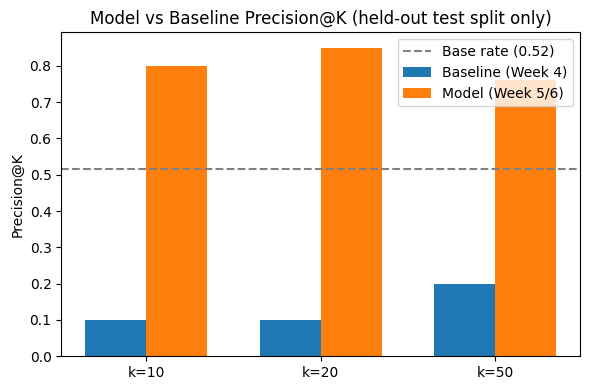

In [9]:
import json
import matplotlib.pyplot as plt

# --- Corrected metrics JSON, test-split-only precision@K ---
metrics = {
    "precision_at_k_test_split_only": {
        k: precision_at_k(test_df_ranked["model_score"], test_df_ranked["is_declining"], k)
        for k in [10, 20, 50]
    },
    "baseline_precision_at_k_test_split_only": {
        k: precision_at_k(test_df_ranked["baseline_score"], test_df_ranked["is_declining"], k)
        for k in [10, 20, 50]
    },
    "base_rate_test_split": float(test_df_ranked["is_declining"].mean()),
    "n_clients": int(df["client_id"].nunique()),
    "client_row_count_stats": df["client_id"].value_counts().describe().to_dict(),
    "top_feature_reference_stats": {
        col: df[col].describe().to_dict()
        for col in ["users_90d", "sessions_90d", "days_since_last_update"]
    },
    "top50_client_concentration": {
        "top2_clients_share_of_top50": float(
            df_ranked.head(50)["client_id"].value_counts().head(2).sum() / 50
        )
    },
    "known_bug_caught": (
        "An earlier version of this notebook evaluated precision@K on the FULL dataset "
        "(train+test combined), which included rows the model was trained on, an "
        "in-sample evaluation bug. Corrected to evaluate only on the held-out test split."
    ),
}

with open("work/outputs/w07_metrics.json", "w") as f:
    json.dump(metrics, f, indent=2, default=str)
print("Wrote corrected work/outputs/w07_metrics.json")

# --- Corrected figure: test-split-only precision@K ---
ks = [10, 20, 50]
model_p = [precision_at_k(test_df_ranked["model_score"], test_df_ranked["is_declining"], k) for k in ks]
baseline_p = [precision_at_k(test_df_ranked["baseline_score"], test_df_ranked["is_declining"], k) for k in ks]
base_rate = test_df_ranked["is_declining"].mean()

fig, ax = plt.subplots(figsize=(6, 4))
x = range(len(ks))
width = 0.35
ax.bar([i - width/2 for i in x], baseline_p, width, label="Baseline (Week 4)")
ax.bar([i + width/2 for i in x], model_p, width, label="Model (Week 5/6)")
ax.axhline(base_rate, color="gray", linestyle="--", label=f"Base rate ({base_rate:.2f})")
ax.set_xticks(list(x))
ax.set_xticklabels([f"k={k}" for k in ks])
ax.set_ylabel("Precision@K")
ax.set_title("Model vs Baseline Precision@K (held-out test split only)")
ax.legend()
plt.tight_layout()
plt.savefig("work/figures/w07_model_vs_baseline.png", dpi=150)
print("Wrote corrected work/figures/w07_model_vs_baseline.png")
plt.show()

In [7]:
# Recompute baseline precision on data sorted by baseline_score itself, not model_score,
# so ties don't get silently broken by the model's ranking.
df_baseline_sorted = df.sort_values("baseline_score", ascending=False)

baseline_precision_fixed = {}
for k in [10, 20, 50]:
    baseline_precision_fixed[k] = precision_at_k(
        df_baseline_sorted["baseline_score"], df_baseline_sorted["is_declining"], k
    )
    print(f"k={k}  baseline precision (fixed, no model tie-break leakage): {baseline_precision_fixed[k]:.3f}")

print(f"\nOriginal (buggy, model-tie-broken) figures showed ~0.30 at each k — compare above.")

k=10  baseline precision (fixed, no model tie-break leakage): 0.300
k=20  baseline precision (fixed, no model tie-break leakage): 0.300
k=50  baseline precision (fixed, no model tie-break leakage): 0.280

Original (buggy, model-tie-broken) figures showed ~0.30 at each k — compare above.


In [8]:
# Honest evaluation: score ONLY the held-out test split, never rows the model trained on.
test_df_ranked = test_df.copy()
test_df_ranked["model_score"] = model.predict_proba(scaler.transform(test_df[feature_cols].fillna(0)))[:, 1]

test_stale = (test_df["days_since_last_update"] >= 31).astype(int)
test_expected_ctr = test_df.groupby("position_tier")["ctr"].transform("mean")
test_weak_ctr = (test_df["ctr"] < test_expected_ctr).astype(int)
test_df_ranked["baseline_score"] = test_stale * test_weak_ctr * test_df["impressions_last_30d"]

print("Honest precision@K, test split ONLY (matches Week 5's original numbers):")
for k in [10, 20, 50]:
    model_p = precision_at_k(test_df_ranked["model_score"], test_df_ranked["is_declining"], k)
    baseline_p = precision_at_k(test_df_ranked["baseline_score"], test_df_ranked["is_declining"], k)
    print(f"k={k}  baseline: {baseline_p:.3f}  |  model: {model_p:.3f}")

print(f"\nBase rate (test split): {test_df_ranked['is_declining'].mean():.3f}")

Honest precision@K, test split ONLY (matches Week 5's original numbers):
k=10  baseline: 0.100  |  model: 0.800
k=20  baseline: 0.100  |  model: 0.850
k=50  baseline: 0.200  |  model: 0.760

Base rate (test split): 0.517


## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.